In [15]:
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

import requests
import matplotlib.pyplot as plt
import seaborn as sns
from scipy import stats


sns.set_style('whitegrid')
sns.set_palette('husl')
plt.rcParams['figure.figsize'] = (12, 6)

print('✅ Bibliotecas importadas com sucesso!')

✅ Bibliotecas importadas com sucesso!


#📌 ETAPA 1: EXTRAÇÃO DE DADOS

In [16]:
url = 'https://raw.githubusercontent.com/alura-cursos/challenge2-data-science/main/TelecomX_Data.json'

try:
    resposta = requests.get(url, timeout=10)
    resposta.raise_for_status()
    dados = resposta.json()
    df = pd.json_normalize(dados)
    print('✅ Dados extraídos com sucesso!')
    print(f'📊 Total de registros: {len(df):,}')
    print(f'📋 Total de colunas: {df.shape[1]}')
except Exception as e:
    print(f'❌ Erro: {e}')

✅ Dados extraídos com sucesso!
📊 Total de registros: 7,267
📋 Total de colunas: 21


In [17]:
print('\n' + '='*60)
print('PRIMEIRAS 5 LINHAS')
print('='*60)
print(df.head())
print('\n' + '='*60)
print('INFORMAÇÕES DO DATASET')
print('='*60)
df.info()


PRIMEIRAS 5 LINHAS
   customerID Churn customer.gender  customer.SeniorCitizen customer.Partner  \
0  0002-ORFBO    No          Female                       0              Yes   
1  0003-MKNFE    No            Male                       0               No   
2  0004-TLHLJ   Yes            Male                       0               No   
3  0011-IGKFF   Yes            Male                       1              Yes   
4  0013-EXCHZ   Yes          Female                       1              Yes   

  customer.Dependents  customer.tenure phone.PhoneService phone.MultipleLines  \
0                 Yes                9                Yes                  No   
1                  No                9                Yes                 Yes   
2                  No                4                Yes                  No   
3                  No               13                Yes                  No   
4                  No                3                Yes                  No   

  internet.I

#🔧 ETAPA 2: LIMPEZA E TRANSFORMAÇÃO

In [18]:
df_clean = df.copy()

print('🔍 Valores nulos:')
nulos = df_clean.isnull().sum()
print(nulos[nulos > 0] if nulos.sum() > 0 else 'Nenhum!')

print(f'\n🔗 Duplicados: {df_clean.duplicated().sum()}')
df_clean = df_clean.drop_duplicates()

# Imputar NaN em colunas numéricas com mediana
numeric_cols = df_clean.select_dtypes(include=[np.number]).columns
for col in numeric_cols:
    if df_clean[col].isnull().sum() > 0:
        df_clean[col].fillna(df_clean[col].median(), inplace=True)
        print(f'✅ NaN em {col} preenchidos com mediana')

# Preencher NaN em categóricas com moda
cat_cols = df_clean.select_dtypes(include='object').columns
for col in cat_cols:
    if df_clean[col].isnull().sum() > 0:
        moda = df_clean[col].mode()[0]
        df_clean[col].fillna(moda, inplace=True)
        print(f'✅ NaN em {col} preenchidos com moda')

print(f'\n✅ Total de NaN restantes: {df_clean.isnull().sum().sum()}')

🔍 Valores nulos:
Nenhum!

🔗 Duplicados: 0

✅ Total de NaN restantes: 0


In [19]:
# Normalizar nomes de colunas
df_clean.columns = df_clean.columns.str.replace('customer.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('phone.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('internet.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('account.', '', regex=False)
df_clean.columns = df_clean.columns.str.replace('Charges.', '', regex=False)

# Converter tipos numéricos
for col in df_clean.columns:
    if df_clean[col].dtype == 'object':
        try:
            df_clean[col] = pd.to_numeric(df_clean[col], errors='ignore')
        except:
            pass

# Criar variável binária de churn
if 'Churn' in df_clean.columns:
    df_clean['Churn_binary'] = (df_clean['Churn'] == 'Yes').astype(int)

print('✅ Dados limpos e transformados!')
print(f'\nFormato final: {df_clean.shape}')

✅ Dados limpos e transformados!

Formato final: (7267, 22)


#📊 ETAPA 3: ANÁLISE DESCRITIVA COMPLETA (9 SEÇÕES)

In [20]:


print('\n📊 Resumo Estatístico:')
print(df_clean.describe().round(2))

print('\n\n📈 Média:')
print(df_clean.mean(numeric_only=True).round(2))

print('\n📊 Mediana:')
print(df_clean.median(numeric_only=True).round(2))

print('\n📉 Desvio Padrão:')
print(df_clean.std(numeric_only=True).round(2))


📊 Resumo Estatístico:
       SeniorCitizen   tenure  Monthly  Churn_binary
count        7267.00  7267.00  7267.00       7267.00
mean            0.16    32.35    64.72          0.26
std             0.37    24.57    30.13          0.44
min             0.00     0.00    18.25          0.00
25%             0.00     9.00    35.42          0.00
50%             0.00    29.00    70.30          0.00
75%             0.00    55.00    89.88          1.00
max             1.00    72.00   118.75          1.00


📈 Média:
SeniorCitizen     0.16
tenure           32.35
Monthly          64.72
Churn_binary      0.26
dtype: float64

📊 Mediana:
SeniorCitizen     0.0
tenure           29.0
Monthly          70.3
Churn_binary      0.0
dtype: float64

📉 Desvio Padrão:
SeniorCitizen     0.37
tenure           24.57
Monthly          30.13
Churn_binary      0.44
dtype: float64


In [21]:


num_cols = df_clean.select_dtypes(include=[np.number]).columns

for col in num_cols:
    if col != 'Churn_binary':
        print(f'\n📊 {col}:')
        print(f'  Mínimo:          {df_clean[col].min():.2f}')
        print(f'  Q1 (25%):        {df_clean[col].quantile(0.25):.2f}')
        print(f'  Mediana (50%):   {df_clean[col].median():.2f}')
        print(f'  Média:           {df_clean[col].mean():.2f}')
        print(f'  Q3 (75%):        {df_clean[col].quantile(0.75):.2f}')
        print(f'  Máximo:          {df_clean[col].max():.2f}')
        print(f'  Amplitude:       {df_clean[col].max() - df_clean[col].min():.2f}')
        print(f'  IQR:             {df_clean[col].quantile(0.75) - df_clean[col].quantile(0.25):.2f}')
        print(f'  Desvio Padrão:   {df_clean[col].std():.2f}')
        print(f'  Variância:       {df_clean[col].var():.2f}')

        cv = (df_clean[col].std() / df_clean[col].mean() * 100) if df_clean[col].mean() != 0 else 0
        print(f'  Coef. Variação:  {cv:.2f}%')

        skewness = stats.skew(df_clean[col])
        if skewness < -1:
            skew_txt = 'Fortemente assimétrica à esquerda'
        elif skewness < -0.5:
            skew_txt = 'Moderadamente assimétrica à esquerda'
        elif skewness > 1:
            skew_txt = 'Fortemente assimétrica à direita'
        elif skewness > 0.5:
            skew_txt = 'Moderadamente assimétrica à direita'
        else:
            skew_txt = 'Aproximadamente simétrica'

        print(f'  Assimetria:      {skewness:.2f} ({skew_txt})')
        print(f'  Curtose:         {stats.kurtosis(df_clean[col]):.2f}')


📊 SeniorCitizen:
  Mínimo:          0.00
  Q1 (25%):        0.00
  Mediana (50%):   0.00
  Média:           0.16
  Q3 (75%):        0.00
  Máximo:          1.00
  Amplitude:       1.00
  IQR:             0.00
  Desvio Padrão:   0.37
  Variância:       0.14
  Coef. Variação:  226.91%
  Assimetria:      1.83 (Fortemente assimétrica à direita)
  Curtose:         1.34

📊 tenure:
  Mínimo:          0.00
  Q1 (25%):        9.00
  Mediana (50%):   29.00
  Média:           32.35
  Q3 (75%):        55.00
  Máximo:          72.00
  Amplitude:       72.00
  IQR:             46.00
  Desvio Padrão:   24.57
  Variância:       603.77
  Coef. Variação:  75.96%
  Assimetria:      0.24 (Aproximadamente simétrica)
  Curtose:         -1.39

📊 Monthly:
  Mínimo:          18.25
  Q1 (25%):        35.42
  Mediana (50%):   70.30
  Média:           64.72
  Q3 (75%):        89.88
  Máximo:          118.75
  Amplitude:       100.50
  IQR:             54.45
  Desvio Padrão:   30.13
  Variância:       907.79
  Co

In [22]:

cat_cols = df_clean.select_dtypes(include='object').columns

for col in cat_cols[:10]:
    if col not in ['customerID', 'Churn']:
        print(f'\n📌 {col}:')
        value_counts = df_clean[col].value_counts()
        percentages = df_clean[col].value_counts(normalize=True) * 100

        for val, count, pct in zip(value_counts.index, value_counts.values, percentages.values):
            bar_length = int(pct / 2)
            bar = '█' * bar_length
            print(f'  {str(val):<20} {count:>6,} ({pct:>5.1f}%) {bar}')

        print(f'  └─ Total de categorias: {df_clean[col].nunique()}')


📌 gender:
  Male                  3,675 ( 50.6%) █████████████████████████
  Female                3,592 ( 49.4%) ████████████████████████
  └─ Total de categorias: 2

📌 Partner:
  No                    3,749 ( 51.6%) █████████████████████████
  Yes                   3,518 ( 48.4%) ████████████████████████
  └─ Total de categorias: 2

📌 Dependents:
  No                    5,086 ( 70.0%) ██████████████████████████████████
  Yes                   2,181 ( 30.0%) ███████████████
  └─ Total de categorias: 2

📌 PhoneService:
  Yes                   6,560 ( 90.3%) █████████████████████████████████████████████
  No                      707 (  9.7%) ████
  └─ Total de categorias: 2

📌 MultipleLines:
  No                    3,495 ( 48.1%) ████████████████████████
  Yes                   3,065 ( 42.2%) █████████████████████
  No phone service        707 (  9.7%) ████
  └─ Total de categorias: 3

📌 InternetService:
  Fiber optic           3,198 ( 44.0%) ██████████████████████
  DSL               

In [23]:


churn_counts = df_clean['Churn'].value_counts()
churn_pct = df_clean['Churn'].value_counts(normalize=True) * 100

print('\n📊 Distribuição:')
print(df_clean['Churn'].value_counts())

print('\n📈 Métricas:')
for cat, count, pct in zip(churn_counts.index, churn_counts.values, churn_pct.values):
    print(f'  {cat}: {count:,} ({pct:.2f}%)')

print(f'\n  Taxa de Churn:    {churn_pct["Yes"]:.2f}%')
print(f'  Taxa de Retenção: {churn_pct["No"]:.2f}%')
print(f'  Razão Churn/Não:  1:{churn_counts["No"]/churn_counts["Yes"]:.2f}')


📊 Distribuição:
Churn
No     5174
Yes    1869
        224
Name: count, dtype: int64

📈 Métricas:
  No: 5,174 (71.20%)
  Yes: 1,869 (25.72%)
  : 224 (3.08%)

  Taxa de Churn:    25.72%
  Taxa de Retenção: 71.20%
  Razão Churn/Não:  1:2.77


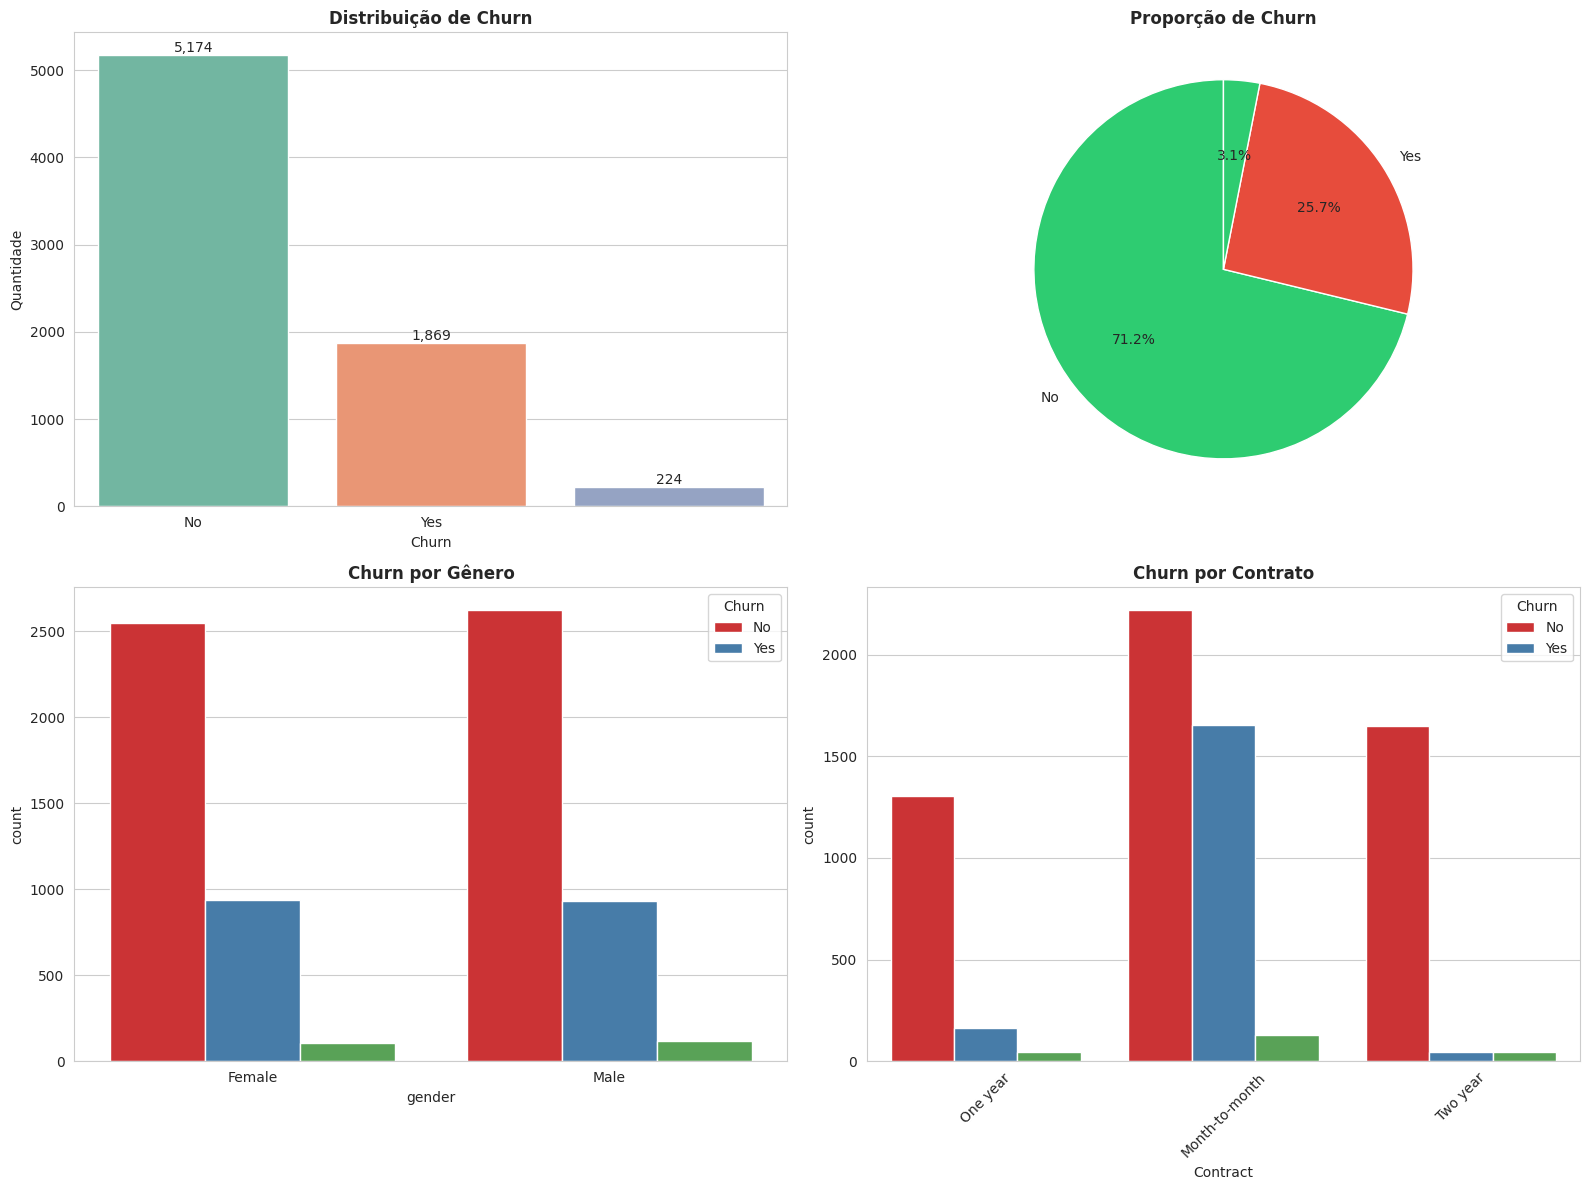

In [24]:


fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# 1. Contagem
sns.countplot(x='Churn', data=df_clean, ax=axes[0, 0], palette='Set2')
axes[0, 0].set_title('Distribuição de Churn', fontsize=12, fontweight='bold')
axes[0, 0].set_xlabel('Churn')
axes[0, 0].set_ylabel('Quantidade')
for p in axes[0, 0].patches:
    height = p.get_height()
    axes[0, 0].text(p.get_x() + p.get_width()/2., height,
                f'{int(height):,}', ha='center', va='bottom')

# 2. Pizza
axes[0, 1].pie(churn_counts, labels=churn_counts.index, autopct='%1.1f%%',
           colors=['#2ecc71', '#e74c3c'], startangle=90)
axes[0, 1].set_title('Proporção de Churn', fontsize=12, fontweight='bold')

# 3. Por Gênero
if 'gender' in df_clean.columns:
    sns.countplot(x='gender', hue='Churn', data=df_clean, ax=axes[1, 0], palette='Set1')
    axes[1, 0].set_title('Churn por Gênero', fontsize=12, fontweight='bold')

# 4. Por Contrato
if 'Contract' in df_clean.columns:
    sns.countplot(x='Contract', hue='Churn', data=df_clean, ax=axes[1, 1], palette='Set1')
    axes[1, 1].set_title('Churn por Contrato', fontsize=12, fontweight='bold')
    plt.setp(axes[1, 1].xaxis.get_majorticklabels(), rotation=45)

plt.tight_layout()
plt.show()

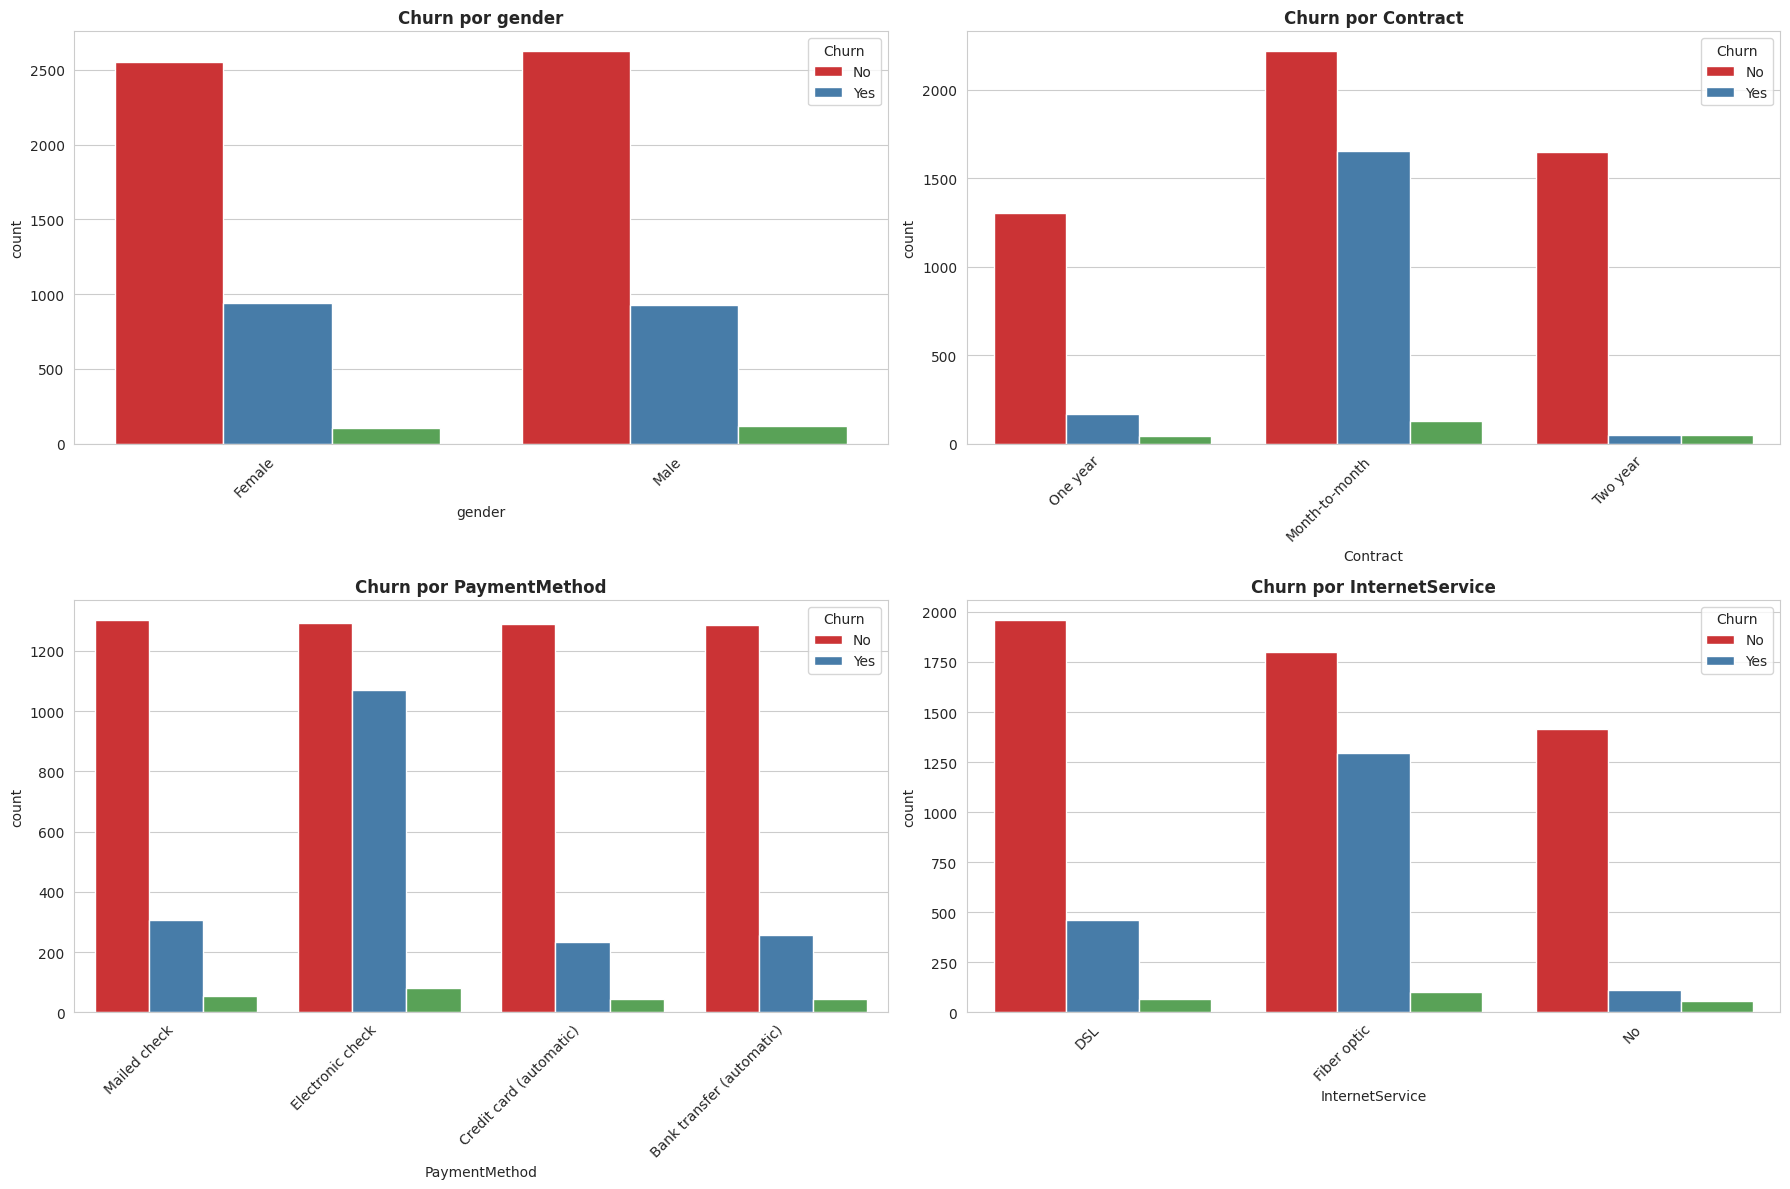


📊 Taxa de Churn por Categoria:

gender:
  Female: 26.1%
  Male: 25.3%

Contract:
  Month-to-month: 41.3%
  One year: 10.9%
  Two year: 2.8%

PaymentMethod:
  Bank transfer (automatic): 16.2%
  Credit card (automatic): 14.8%
  Electronic check: 43.8%
  Mailed check: 18.5%

InternetService:
  DSL: 18.4%
  Fiber optic: 40.6%
  No: 7.1%


In [25]:

cat_vars = ['gender', 'Contract', 'PaymentMethod', 'InternetService']

fig, axes = plt.subplots(2, 2, figsize=(18, 12))
axes = axes.ravel()

for idx, col in enumerate(cat_vars):
    if col in df_clean.columns:
        sns.countplot(x=col, hue='Churn', data=df_clean, ax=axes[idx], palette='Set1')
        axes[idx].set_title(f'Churn por {col}', fontsize=12, fontweight='bold')
        plt.setp(axes[idx].xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

# Taxa de churn
print('\n📊 Taxa de Churn por Categoria:')
for col in cat_vars:
    if col in df_clean.columns:
        print(f'\n{col}:')
        churn_by_cat = pd.crosstab(df_clean[col], df_clean['Churn'], normalize='index') * 100
        for cat in churn_by_cat.index:
            churn_rate = churn_by_cat.loc[cat, 'Yes'] if 'Yes' in churn_by_cat.columns else 0
            print(f'  {cat}: {churn_rate:.1f}%')

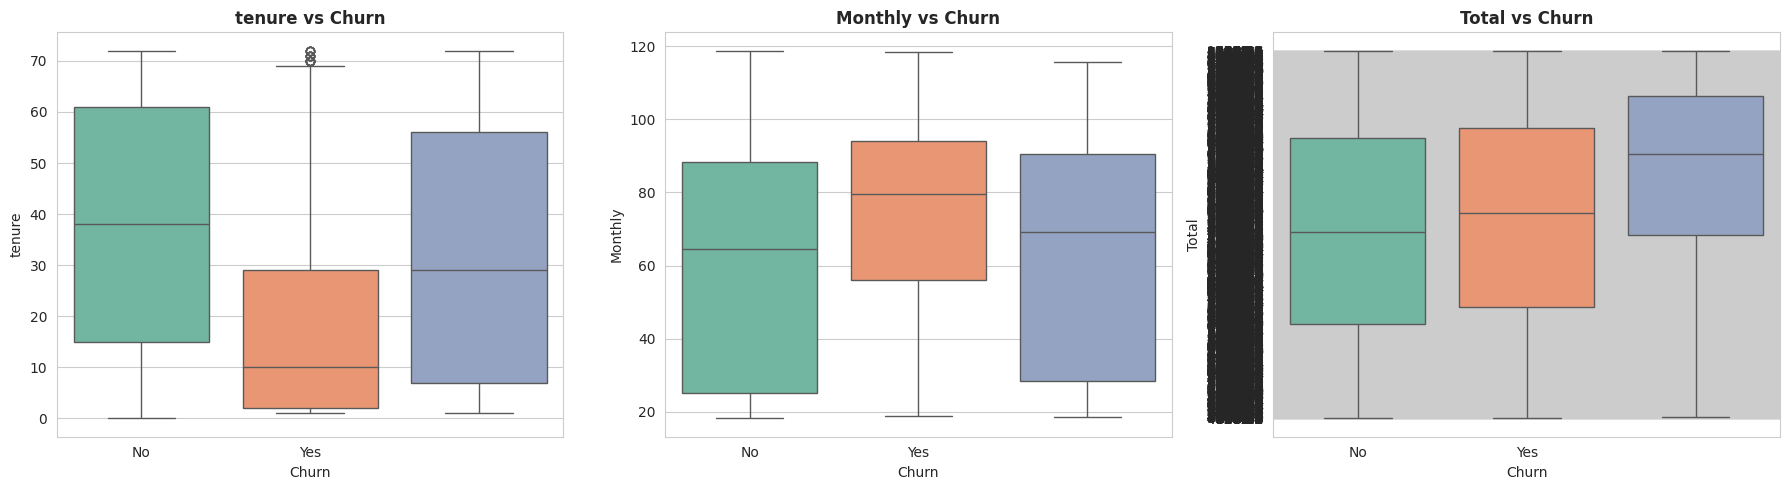


📊 Comparação por Grupo de Churn:

tenure:
        count   mean    std  min   25%   50%   75%   max
Churn                                                   
        224.0  31.57  25.00  1.0   7.0  29.0  56.0  72.0
No     5174.0  37.57  24.11  0.0  15.0  38.0  61.0  72.0
Yes    1869.0  17.98  19.53  1.0   2.0  10.0  29.0  72.0

Monthly:
        count   mean    std    min    25%    50%    75%     max
Churn                                                          
        224.0  63.41  31.39  18.75  28.42  69.10  90.41  115.55
No     5174.0  61.27  31.09  18.25  25.10  64.43  88.40  118.75
Yes    1869.0  74.44  24.67  18.85  56.15  79.65  94.20  118.35

Total:
      count unique    top freq
Churn                         
        224    223  19.55    2
No     5174   4966          11
Yes    1869   1732   20.2    6


In [26]:


num_vars = ['tenure', 'Monthly', 'Total']
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for idx, col_pattern in enumerate(num_vars):
    matching_cols = [c for c in df_clean.columns if col_pattern in c]
    if matching_cols:
        col = matching_cols[0]
        sns.boxplot(x='Churn', y=col, data=df_clean, ax=axes[idx], palette='Set2')
        axes[idx].set_title(f'{col} vs Churn', fontsize=12, fontweight='bold')

plt.tight_layout()
plt.show()

# Estatísticas por grupo
print('\n📊 Comparação por Grupo de Churn:')
for col_pattern in num_vars:
    matching_cols = [c for c in df_clean.columns if col_pattern in c]
    if matching_cols:
        col = matching_cols[0]
        print(f'\n{col}:')
        print(df_clean.groupby('Churn')[col].describe().round(2))

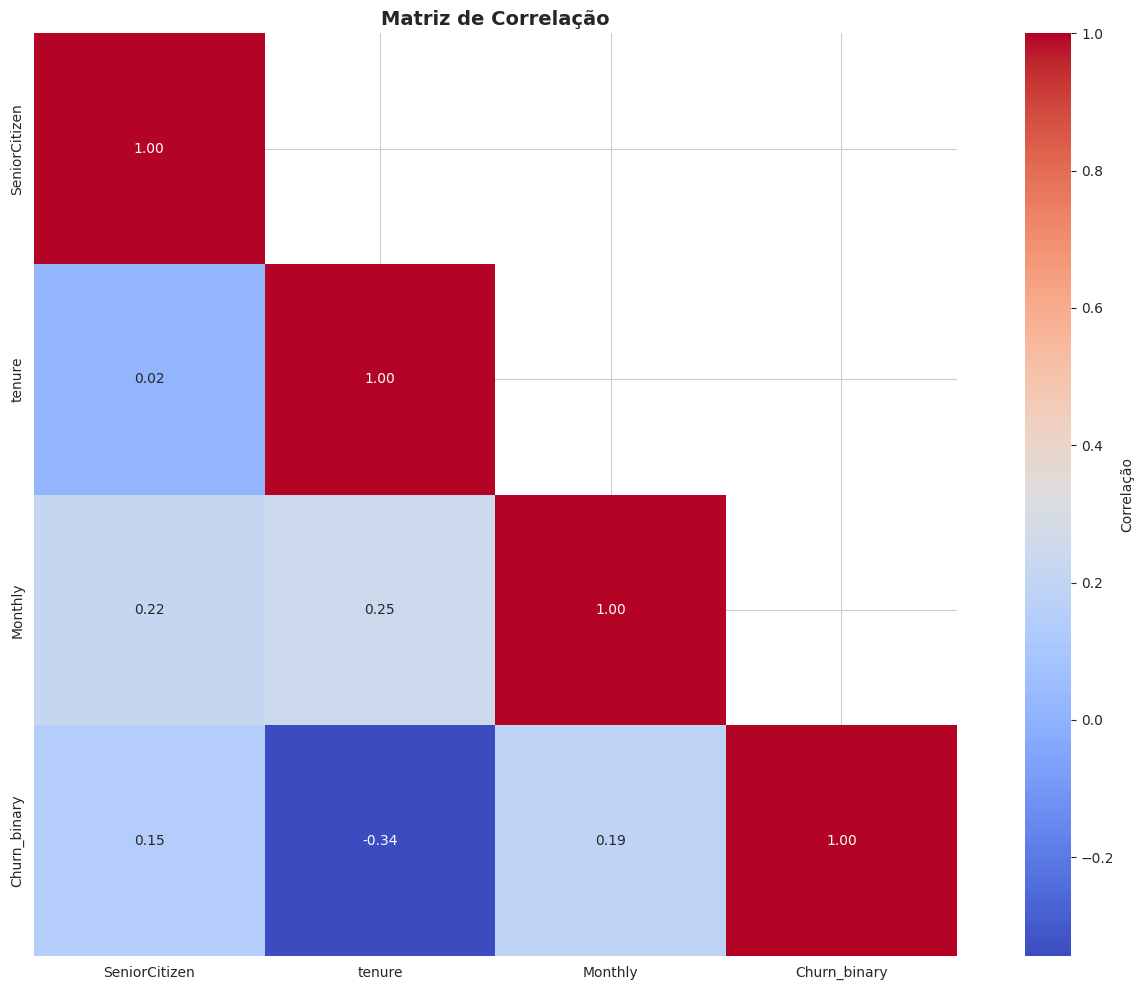


🔗 Top 10 Correlações com Churn_binary:
Churn_binary     1.000
Monthly          0.190
SeniorCitizen    0.147
tenure          -0.344
Name: Churn_binary, dtype: float64


In [27]:



df_corr = df_clean.select_dtypes(include=[np.number])

correlacao = df_corr.corr()


fig, ax = plt.subplots(figsize=(14, 10))
mask = np.triu(np.ones_like(correlacao, dtype=bool), k=1)
sns.heatmap(correlacao, annot=True, cmap='coolwarm', fmt='.2f',
           cbar_kws={'label': 'Correlação'}, square=True, mask=mask, ax=ax)
ax.set_title('Matriz de Correlação', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()


print('\n🔗 Top 10 Correlações com Churn_binary:')
churn_corr = correlacao['Churn_binary'].sort_values(ascending=False)
print(churn_corr.round(3))

In [28]:



tenure_col = [c for c in df_clean.columns if 'tenure' in c][0] if any('tenure' in c for c in df_clean.columns) else None
monthly_col = [c for c in df_clean.columns if 'Monthly' in c][0] if any('Monthly' in c for c in df_clean.columns) else None

resumo_metrics = {
    'Total de Clientes': f'{len(df_clean):,}',
    'Taxa de Churn': f"{churn_pct['Yes']:.2f}%",
    'Clientes em Risco': f"{churn_counts.get('Yes', 0):,}",
    'Tenure Médio': f"{df_clean[tenure_col].mean():.1f} meses" if tenure_col else 'N/A',
    'Tenure Mediano': f"{df_clean[tenure_col].median():.1f} meses" if tenure_col else 'N/A',
    'Cobrança Mensal Média': f"R$ {df_clean[monthly_col].mean():.2f}" if monthly_col else 'N/A',
}

print('\n📊 Métricas Principais:')
for metric, value in resumo_metrics.items():
    print(f'  {metric:<30} {value}')




📊 Métricas Principais:
  Total de Clientes              7,267
  Taxa de Churn                  25.72%
  Clientes em Risco              1,869
  Tenure Médio                   32.3 meses
  Tenure Mediano                 29.0 meses
  Cobrança Mensal Média          R$ 64.72
